# 02. 복지마을 방송국 에이전트 — Supabase 기반

> **선행 작업**: `01_data_ingestion.ipynb`를 먼저 실행해서 Supabase에 데이터 적재 완료해야 합니다.

## 변경 사항 (v3 → v4)
- `welfare_search_node`: 공공 API 직접 호출 → **Supabase 조회**로 전환
- `eligibility_check`: API의 supportConditions 호출 → **Supabase 조인 쿼리**
- 응답 속도 대폭 개선 (API 응답 대기 없음), 토큰/호출량 절감

## 데이터 흐름

```
[UI 버튼 클릭]
   mode = "personal" or "broadcast"
        │
        ▼
   dispatcher (결정적 라우터)
        │
        ├ personal:
        │   welfare_search (Supabase 쿼리)
        │   ─► eligibility_check (Supabase JOIN, 규칙 매칭)
        │   ─► present_results (Gemini가 따뜻하게 정리)
        │   ─► END
        │
        │   ▼ [사용자 피드백 2턴]
        │
        │   feedback_analyzer ─► escalate_email (SMTP) ─► END
        │
        └ broadcast:
            easy_translate ─► broadcast_script ─► END
```


## 1. 환경 설정 & 키 로드

In [1]:
# !pip install -r requirements.txt


In [4]:
from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(".env", override=True)

# AnySign 우회: API.txt에서 Gemini 키 자동 로드
api_txt = Path("API.txt")
if api_txt.exists():
    for line in api_txt.read_text(encoding="utf-8", errors="ignore").splitlines():
        token = line.strip().split("=")[-1].strip().strip('"').strip("'")
        if token.startswith("AIza") and len(token) > 30:
            os.environ["GOOGLE_API_KEY"] = token
            print(f"✅ API.txt에서 GOOGLE_API_KEY 로드: {token[:10]}...{token[-4:]}")
            break

REQUIRED = ["GOOGLE_API_KEY", "SUPABASE_URL", "SUPABASE_ANON_KEY"]
missing = [k for k in REQUIRED if not os.getenv(k) or str(os.getenv(k)).startswith(("AIza...", "https://your"))]
if missing:
    print(f"⚠️ 필수 키 누락: {missing}")
else:
    print("✅ 필수 키 모두 확인")

HAS_SMTP = all(os.getenv(k) for k in ("SMTP_HOST", "SMTP_USER", "SMTP_PASS"))
USE_LANGFUSE = bool(os.getenv("LANGFUSE_PUBLIC_KEY") and os.getenv("LANGFUSE_SECRET_KEY"))
print(f"SMTP: {HAS_SMTP}  |  LangFuse: {USE_LANGFUSE}")


✅ API.txt에서 GOOGLE_API_KEY 로드: AIzaSyAbTW...t9jY
✅ 필수 키 모두 확인
SMTP: False  |  LangFuse: True


## 2. Supabase 클라이언트 (anon key, 읽기 전용)

In [5]:
from supabase import create_client, Client
from typing import List, Dict, Any, Optional

SB: Client = create_client(os.getenv("SUPABASE_URL"), os.getenv("SUPABASE_ANON_KEY"))

# 연결 + 데이터 존재 확인
try:
    r = SB.table("welfare_services").select("id", count="exact").limit(1).execute()
    print(f"✅ Supabase 연결 OK (welfare_services: {r.count:,} 행)")
    if r.count == 0:
        print("⚠️ 데이터가 비어있습니다. 01_data_ingestion.ipynb를 먼저 실행하세요.")
except Exception as e:
    print(f"❌ Supabase: {e}")


✅ Supabase 연결 OK (welfare_services: 15,528 행)


## 3. LLM (Gemini) + Tavily 보완

In [6]:
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import Literal

llm = init_chat_model("google_genai:gemini-2.5-flash", temperature=0.3)
classifier_llm = init_chat_model("google_genai:gemini-2.5-flash", temperature=0.0)

HAS_TAVILY = bool(os.getenv("TAVILY_API_KEY") and not os.getenv("TAVILY_API_KEY","").startswith("tvly-..."))
tavily_tool = None
if HAS_TAVILY:
    from langchain_tavily import TavilySearch
    tavily_tool = TavilySearch(
        max_results=3, topic="general",
        include_domains=["bokjiro.go.kr", "gov.kr", "mohw.go.kr", "korea.kr"],
        search_depth="advanced",
    )
print("LLM: Gemini 2.5 Flash | Tavily:", "ON" if tavily_tool else "OFF")


LLM: Gemini 2.5 Flash | Tavily: ON


## 4. 자격 매칭 엔진 (Supabase JOIN 기반)

`welfare_support_conditions` 테이블의 boolean 컬럼들을 사용자 프로필과 매칭합니다.
LLM 환각 0, 결정적 판단.


In [7]:
INCOME_BANDS = [
    ("income_band_50",      1_196_000),
    ("income_band_75",      1_794_000),
    ("income_band_100",     2_392_000),
    ("income_band_200",     4_784_000),
    ("income_band_over200", 10**12),
]

def infer_is_rural(region: str) -> bool:
    """시도/시군구에서 농어촌 여부 자동 추론.
    - xx군 (예: 부여군, 진도군) → True
    - 광역시/특별시 구·시·동 → False
    """
    if not region: return False
    parts = region.split()
    # 시군구 이름이 "xx군"으로 끝나면 농어촌
    if len(parts) >= 2 and parts[1].endswith("군"):
        return True
    # 도 단위만 명시한 경우 (예: "충청남도") - 보수적으로 False
    return False

class UserProfile(BaseModel):
    age: int
    region: str = ""
    monthly_income: Optional[int] = None
    has_disability: bool = False
    is_rural: Optional[bool] = None   # None이면 region에서 자동 추론
    is_single_household: bool = False
    is_single_parent: bool = False

    def model_post_init(self, __context):
        # is_rural이 명시되지 않으면 region에서 추론
        if self.is_rural is None:
            self.is_rural = infer_is_rural(self.region)

def is_eligible(profile: UserProfile, cond: dict) -> tuple[bool, str]:
    """welfare_support_conditions 행을 받아 자격 여부 판정"""
    if not cond:
        return True, "지원조건 정보 없음"

    if cond.get("age_start") and profile.age < cond["age_start"]:
        return False, f"연령 {cond['age_start']}세 이상 대상"
    if cond.get("age_end") and profile.age > cond["age_end"]:
        return False, f"연령 {cond['age_end']}세 이하 대상"

    # 소득 - 어떤 구간이라도 매칭되면 OK
    has_income_constraint = any(cond.get(c) for c, _ in INCOME_BANDS)
    if has_income_constraint and profile.monthly_income is not None:
        ok = any(cond.get(c) and profile.monthly_income <= lim for c, lim in INCOME_BANDS)
        if not ok:
            return False, "소득 구간 초과"

    if cond.get("disabled") and not profile.has_disability:
        return False, "장애인 대상"
    if cond.get("single_parent") and not profile.is_single_parent:
        return False, "한부모/조손 대상"
    if cond.get("single_household") and not profile.is_single_household:
        return False, "1인가구 대상"

    return True, "자격 매칭"

print("자격 매칭 엔진 준비 완료")


자격 매칭 엔진 준비 완료


## 5. SMTP 헬퍼 (피드백 → 민원 담당자)

In [8]:
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.utils import formataddr
from datetime import datetime

def send_complaint_email(subject: str, body: str, to_addr: Optional[str] = None) -> dict:
    to_addr = to_addr or os.getenv("SMTP_TO", "")
    host = os.getenv("SMTP_HOST", "")
    port = int(os.getenv("SMTP_PORT", "587"))
    user = os.getenv("SMTP_USER", "")
    pw   = os.getenv("SMTP_PASS", "")
    from_name = os.getenv("SMTP_FROM_NAME", "복지마을 방송국")

    msg = MIMEMultipart()
    msg["From"] = formataddr((from_name, user or "noreply@example.com"))
    msg["To"] = to_addr or "민원담당자@미설정"
    msg["Subject"] = subject
    msg["Date"] = datetime.now().strftime("%a, %d %b %Y %H:%M:%S +0900")
    msg.attach(MIMEText(body, "plain", "utf-8"))

    if not (host and user and pw and to_addr):
        print("=" * 60)
        print(f"📧 [SMTP 미설정 - 미리보기]")
        print(f"To: {msg['To']} | Subject: {subject}")
        print("-" * 60)
        print(body)
        print("=" * 60)
        return {"status": "preview", "to": msg["To"], "subject": subject}

    with smtplib.SMTP(host, port) as srv:
        srv.starttls()
        srv.login(user, pw)
        srv.sendmail(user, [to_addr], msg.as_string())
    print(f"✅ SMTP 발송 완료 → {to_addr}")
    return {"status": "sent", "to": to_addr, "subject": subject}

print("SMTP 헬퍼 준비 완료 (모드:", "발송" if HAS_SMTP else "미리보기", ")")


SMTP 헬퍼 준비 완료 (모드: 미리보기 )


## 6. State 정의

In [9]:
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage

class WelfareState(TypedDict, total=False):
    messages: Annotated[list[BaseMessage], add_messages]
    mode: Literal["personal", "broadcast"]   # ← UI 버튼이 결정
    user_profile: Dict[str, Any]

    raw_services: List[Dict[str, Any]]
    eligible_benefits: List[Dict[str, Any]]
    presented: bool
    satisfaction: Literal["", "satisfied", "unsatisfied", "needs_more"]
    email_sent: bool
    feedback_summary: str

    easy_text: str
    broadcast_text: str


## 7. 노드 정의 — `welfare_search`는 Supabase 쿼리로 전환

In [10]:
# ============================================================
# [Personal] welfare_search - Supabase 조회 (1차) + Tavily 보완 (2차)
# ============================================================
# ----- LLM 의도 추출기 (사용자 발화 + 프로필 → 검색 키워드·user_type·우선순위) -----
class SearchIntent(BaseModel):
    """사용자 발화·프로필을 분석한 검색 의도"""
    keywords: List[str] = Field(
        description="복지 사업명/지원대상에 들어갈 만한 한국어 키워드 5~10개. "
                    "예: '결혼' → ['결혼','신혼','주거','주택자금','청년']"
    )
    user_type: str = Field(
        default="",
        description="우리 DB user_type 표준값 중 하나 (없으면 빈 문자열): "
                    "노인/장애인/청년/임산부/영유아/다문화/한부모/근로자/구직자/농업인/어업인/학생/저소득"
    )
    intent_summary: str = Field(
        description="사용자가 처한 상황 한 줄 요약 (예: '결혼을 앞둔 청년 단신가구')"
    )

INTENT_PROMPT = """당신은 사용자의 발화와 프로필을 분석해 복지 검색에 사용할 키워드를 추출하는 어시스턴트입니다.

규칙:
- keywords: 한국어 복지 사업명에 들어갈 만한 단어 5~10개. 사용자 발화의 의도(결혼·출산·취업·주거·건강 등)와 직접 관련된 단어, 그리고 인접한 동의어/연관어 포함.
- user_type: DB 표준값 중에서 가장 잘 맞는 하나. 명시적 단서가 없으면 빈 문자열.
- intent_summary: 사용자 상황을 한 줄로.

예시:
입력: 발화="곧 결혼해" / 프로필=33세, 1인가구, 월소득 1억
출력: keywords=['결혼','신혼','주거','주택자금','청년','대출','전세','신혼부부'], user_type='청년', intent_summary='결혼을 앞둔 청년 단신가구'

입력: 발화="기초연금 받을 수 있나" / 프로필=78세, 부여군, 월소득 80만, 1인가구
출력: keywords=['기초연금','노인','어르신','연금','경로','생계지원'], user_type='노인', intent_summary='저소득 농어촌 독거노인'"""

def extract_intent(query: str, profile: dict) -> SearchIntent:
    """Gemini로 발화·프로필 → 검색 의도 추출. 실패 시 빈 의도 반환."""
    try:
        structured = classifier_llm.with_structured_output(SearchIntent)
        prof_txt = (
            f"{profile.get('age','?')}세 / 지역={profile.get('region','?')} / "
            f"월소득 {profile.get('monthly_income','?')}원 / "
            f"가구={'1인' if profile.get('is_single_household') else '복수'}"
            f"{', 한부모' if profile.get('is_single_parent') else ''}"
            f"{', 장애' if profile.get('has_disability') else ''}"
        )
        user_msg = "발화: " + query + " / 프로필: " + prof_txt
        return structured.invoke([
            SystemMessage(content=INTENT_PROMPT),
            HumanMessage(content=user_msg),
        ])
    except Exception as e:
        print(f"  의도 추출 실패 (LLM 오류): {e}")
        # fallback: 정규화된 기본값
        age = (profile or {}).get("age", 0)
        fallback_ut = "노인" if age >= 65 else ("청년" if 18 < age <= 39 else "")
        return SearchIntent(keywords=[], user_type=fallback_ut, intent_summary="")

def welfare_search_node(state: WelfareState) -> dict:
    print("📍 [1/3] welfare_search 진입 → 의도 추출 + Supabase 조회")
    last_user = next((m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None)
    query = last_user.content if last_user else ""
    profile = state.get("user_profile") or {}

    # ── LLM 의도 추출 (한 번 호출) ──
    intent = extract_intent(query, profile)
    kws = intent.keywords or []
    user_type = intent.user_type or ""

    # 시도/시군구 분리
    region_parts = (profile.get("region") or "").split()
    region_sido    = region_parts[0] if len(region_parts) >= 1 else None
    region_sigungu = region_parts[1] if len(region_parts) >= 2 else None

    def _build_or(filters_keywords):
        f = []
        for kw in filters_keywords:
            if not kw: continue
            f.append(f"service_name.ilike.%{kw}%")
            f.append(f"user_type.ilike.%{kw}%")
            f.append(f"service_field.ilike.%{kw}%")
            f.append(f"target_description.ilike.%{kw}%")
        return ",".join(f)

    services = []
    select_cols = ("service_id, source, service_name, agency_name, support_content, "
                   "apply_method, detail_url, target_description, region_sido, region_sigungu, "
                   "user_type, service_field")

    # ── 행정안전부 (전국) ──
    q = (SB.table("welfare_services").select(select_cols).eq("source", "행정안전부"))
    or_str = _build_or(kws + ([user_type] if user_type else []))
    if or_str: q = q.or_(or_str)
    q = q.limit(25)
    try: services.extend(q.execute().data or [])
    except Exception as e: print(f"  공공 조회 오류: {e}")

    # ── 지자체 (시도 + 시군구 정밀) ──
    if region_sido:
        q2 = (SB.table("welfare_services").select(select_cols)
              .eq("source", "지자체").eq("region_sido", region_sido))
        if region_sigungu:
            q2 = q2.or_(f"region_sigungu.eq.{region_sigungu},region_sigungu.is.null")
        if or_str: q2 = q2.or_(or_str)
        q2 = q2.limit(25)
        try: services.extend(q2.execute().data or [])
        except Exception as e: print(f"  지자체 조회 오류: {e}")

    # 중복 제거 (service_name 기준) - 먼저 DB 결과만 통합
    seen, unique = set(), []
    for s in services:
        nm = s.get("service_name","")
        if nm and nm not in seen:
            seen.add(nm); unique.append(s)

    # ── 2차: Tavily는 DB 서비스의 정보 증강용으로만 사용 (단독 결과 추가 X) ──
    primary_kw = kws[0] if kws else ""
    augmented_count = 0
    if tavily_tool and primary_kw and unique:
        try:
            tv_q = f"{primary_kw} {profile.get('region','')} 복지 지원 신청"
            print(f"  🔍 Tavily 호출: query='{tv_q}'")
            raw = tavily_tool.invoke({"query": tv_q})
            tv_results = (raw.get("results",[]) if isinstance(raw,dict) else raw)[:5]
            print(f"  📥 Tavily 결과: {len(tv_results)}건")
            for i, tv in enumerate(tv_results, 1):
                title = tv.get("title","")[:60]
                url = tv.get("url","")[:50]
                snippet = (tv.get("content","") or "")[:100].replace("\n"," ")
                print(f"     [{i}] {title}")
                print(f"         URL: {url}")
                print(f"         내용: {snippet}...")
            # 매칭 시도
            print(f"  🔗 DB 서비스명 ↔ Tavily 매칭 시도 ({len(unique)}개 DB 서비스 검사)")
            # 의미 없는 일반 단어 (stopwords) - 매칭 정확도 향상용
            STOP_TOKENS = {"지원","사업","제도","서비스","대상","신청","안내","정보","비용","수당","수급",
                           "지급","대상자","사례","상담","처리","관리","운영","교육","조례","사례집"}
            import re
            def _tokens(s):
                return [t for t in re.findall(r"[가-힣]{2,}|[A-Za-z]{3,}", s or "") if t and t not in STOP_TOKENS]

            # 어떤 Tavily 결과가 DB 매칭됐는지 추적 (매칭 안 된 건 = 한시/신규 사업 후보)
            matched_tv_indices = set()
            for s in unique:
                svc_name = s.get("service_name","")
                if not svc_name: continue
                svc_tokens = _tokens(svc_name)
                if len(svc_tokens) < 2: continue
                best_tv_idx, best_hits = None, 0
                for idx, tv in enumerate(tv_results):
                    tv_text = (str(tv.get("title","")) + " " + str(tv.get("content",""))).strip()
                    hits = sum(1 for t in svc_tokens if t in tv_text)
                    if hits > best_hits:
                        best_hits, best_tv_idx = hits, idx
                # 엄격한 임계값: 서비스 핵심 토큰 중 최소 2개 AND 비율 60% 이상
                if best_tv_idx is not None and best_hits >= 2 and best_hits >= len(svc_tokens) * 0.6:
                    best_tv = tv_results[best_tv_idx]
                    s["tavily_augment"] = {
                        "snippet": (best_tv.get("content","") or "")[:250],
                        "url": best_tv.get("url",""),
                        "title": best_tv.get("title",""),
                        "matched_tokens": best_hits,
                    }
                    augmented_count += 1
                    matched_tv_indices.add(best_tv_idx)
                    matched_tokens_str = "/".join([t for t in svc_tokens if t in (str(best_tv.get("title",""))+str(best_tv.get("content","")))])
                    print(f"     ✨ 증강(매칭토큰 {best_hits}/{len(svc_tokens)}): '{svc_name}' ← [{best_tv.get('title','')[:40]}]  공통토큰=[{matched_tokens_str}]")

            # ── 기획서 ② 보완: DB 매칭 안된 Tavily 결과는 *한시·신규 지자체 사업* 후보로 추가 ──
            # 단, 의도 키워드(kws) 중 최소 1개가 결과에 포함되어야 잡음 방지
            supplement_added = 0
            for idx, tv in enumerate(tv_results):
                if idx in matched_tv_indices: continue
                tv_text = (str(tv.get("title","")) + " " + str(tv.get("content",""))).strip()
                # 의도 키워드 적어도 1개 + 의미있는 토큰 길이 검증
                intent_hits = sum(1 for kw in kws if kw and kw in tv_text)
                if intent_hits < 1 or len(tv_text) < 50: continue
                unique.append({
                    "service_id": None,
                    "source": "Tavily(웹보완)",
                    "service_name": (tv.get("title","") or "")[:80],
                    "agency_name": "웹검색 — 한시/신규 사업 후보",
                    "support_content": (tv.get("content","") or "")[:250],
                    "apply_method": "",
                    "detail_url": tv.get("url",""),
                    "target_description": "",
                    "region_sido": region_sido,
                    "region_sigungu": None,
                    "user_type": user_type or "",
                    "service_field": "",
                })
                supplement_added += 1
                print(f"     ➕ 한시/신규 보완: '{tv.get('title','')[:60]}' (의도키워드 {intent_hits}개 매칭)")
            if supplement_added:
                print(f"  ➕ DB에 없던 한시/신규 사업 {supplement_added}건 추가 (Tavily 보완)")
            print(f"  ✅ Tavily 증강 완료: {augmented_count}건 증강됨 (DB는 그대로, 증강 정보만 추가)")
        except Exception as e:
            print(f"  ❌ Tavily 오류 (증강 스킵): {e}")

    # 의도 매칭 점수: 사용자 의도 키워드가 service_name·target에 포함된 갯수
    def _intent_score(s):
        text = " ".join([str(s.get(k,"")) for k in ["service_name","target_description","support_content","user_type","service_field"]])
        return sum(1 for kw in kws if kw and kw in text)
    for s in unique:
        s["_intent_score"] = _intent_score(s)
    # 정렬 - intent_score 내림차순으로 먼저 (eligibility_node에서 지역 정렬과 결합)
    unique.sort(key=lambda s: -s.get("_intent_score", 0))

    # 통계
    by_source = {}
    for s in unique:
        by_source[s.get("source","?")] = by_source.get(s.get("source","?"), 0) + 1
    source_summary = ", ".join([f"{k} {v}건" for k, v in by_source.items()])
    kw_show = ", ".join(kws) if kws else "-"
    ut_show = user_type or "-"
    sig_show = region_sigungu or "-"
    msg = (
        f"🔎 검색 결과: 총 {len(unique)}건  ({source_summary})\n"
        f"   ↳ 의도: {intent.intent_summary or '-'}\n"
        f"   ↳ 키워드: [{kw_show}]\n"
        f"   ↳ 필터: 지역={region_sido}/{sig_show}, 사용자유형={ut_show}\n"
        f"   ↳ Tavily 증강: {augmented_count}건 (기존 DB 서비스 보충정보) + 한시/신규 보완 추가"
    )
    return {"raw_services": unique, "messages": [AIMessage(content=msg)]}

# ============================================================
# [Personal] eligibility_check - Supabase JOIN
# ============================================================
def eligibility_node(state: WelfareState) -> dict:
    print("📍 [2/3] eligibility_check 진입 → 자격 매칭 (규칙기반)")
    pdict = state.get("user_profile") or {}
    if not pdict.get("age"):
        return {"eligible_benefits": [],
                "messages":[AIMessage(content="자격 확인을 위해 나이/지역/소득 정보가 필요합니다.")]}
    profile = UserProfile(**{k:v for k,v in pdict.items() if k in UserProfile.model_fields})

    # 시도/시군구 분리 (정렬용)
    region_parts = (pdict.get("region") or "").split()
    user_sigungu = region_parts[1] if len(region_parts) >= 2 else None

    services = state.get("raw_services", [])
    matched = []
    for s in services:
        if s.get("source") == "행정안전부" and s.get("service_id"):
            try:
                cr = (SB.table("welfare_support_conditions")
                      .select("*").eq("service_id", s["service_id"])
                      .limit(1).execute())
                cond = cr.data[0] if cr.data else {}
                ok, reason = is_eligible(profile, cond)
                if ok:
                    matched.append({**s, "match_reason": reason})
            except Exception as e:
                continue
        else:
            # 지자체: supportConditions 테이블도 함께 조회해 자격 확인
            if s.get("source") == "지자체" and s.get("service_id"):
                try:
                    cr = (SB.table("welfare_support_conditions")
                          .select("*").eq("service_id", s["service_id"])
                          .limit(1).execute())
                    cond = cr.data[0] if cr.data else {}
                    ok, reason = is_eligible(profile, cond)
                    if ok:
                        matched.append({**s, "match_reason": reason})
                except Exception:
                    matched.append({**s, "match_reason": "지자체 (추가확인)"})
            elif s.get("source", "").startswith("Tavily"):
                # Tavily 보완(한시/신규)은 자격 검증 불가 → 그대로 노출하되 표시
                matched.append({**s, "match_reason": "한시/신규 사업 (담당자 확인 필요)"})
            else:
                matched.append({**s, "match_reason": "지자체/웹 (추가확인)"})

    # ── 의도 무관 결과 필터링 (raw_services에 _intent_score가 있을 때만) ──
    has_intent_data = any("_intent_score" in m for m in matched)
    if has_intent_data:
        before_n = len(matched)
        matched_with_intent = [m for m in matched if m.get("_intent_score", 0) > 0]
        # 의도 매칭이 너무 적으면 (3개 미만) 필터 완화
        if len(matched_with_intent) >= 3:
            matched = matched_with_intent
            print(f"      [의도필터] {before_n}건 → {len(matched)}건 (intent_score>0)")
        else:
            print(f"      [의도필터] 매칭 {len(matched_with_intent)}건 → 너무 적어 전체 유지")

    # 출처별로 분리 후 의도점수 내림차순 정렬, 그리고 인터리빙 (지자체 ↔ 행정안전부 교차)
    def _local_rank(s):
        sgg = s.get("region_sigungu")
        if user_sigungu and sgg == user_sigungu: return 0  # 시군구 정확 매칭
        if not sgg: return 1                                # 도 단위
        return 2                                            # 그 외 지자체
    local_list = sorted(
        [m for m in matched if m.get("source") == "지자체"],
        key=lambda s: (-s.get("_intent_score", 0), _local_rank(s))
    )
    central_list = sorted(
        [m for m in matched if m.get("source") == "행정안전부"],
        key=lambda s: -s.get("_intent_score", 0)
    )
    others = [m for m in matched if m.get("source") not in ("지자체", "행정안전부")]
    # 균등 인터리브: 지자체 1 → 행정안전부 1 → 지자체 2 → ... (사용자에게 두 출처 모두 보장)
    interleaved = []
    for i in range(max(len(local_list), len(central_list))):
        if i < len(local_list):   interleaved.append(local_list[i])
        if i < len(central_list): interleaved.append(central_list[i])
    matched = interleaved + others
    print(f"      [인터리브] 지자체 {len(local_list)} ↔ 행정안전부 {len(central_list)} = 총 {len(matched)}건")

    # 자격 매칭 통계: 매칭/탈락 카운트 + 출처별
    total = len(services)
    by_source = {}
    for s in matched:
        by_source[s.get("source","?")] = by_source.get(s.get("source","?"), 0) + 1
    src_show = ", ".join([f"{k} {v}건" for k, v in by_source.items()])

    tags = []
    if profile.is_single_household: tags.append("1인가구")
    if profile.is_single_parent:    tags.append("한부모")
    if profile.has_disability:      tags.append("장애")
    if profile.is_rural:            tags.append("농어촌")
    profile_summary = f"{profile.age}세 / {profile.region or '?'} / 월소득 {profile.monthly_income or '?'}원 / {'·'.join(tags) if tags else '-'}"

    msg = f"✅ 자격 매칭: {len(matched)}/{total}건 통과 ({src_show})\n   ↳ 프로필: {profile_summary}"
    return {"eligible_benefits": matched, "messages": [AIMessage(content=msg)]}

# ============================================================
# [Personal] present_results
# ============================================================
PRESENT_PROMPT = """당신은 어르신·주민에게 복지 정보를 친절하게 안내하는 동네 상담사입니다.
다음 형식으로 출력하세요:

1) 인삿말 한 줄 (어르신/주민 호칭)
2) 사용자 의도(infer된 상황) 기반 안내 한 줄. 예: "출산하신 한부모 가정에 맞춰 다음 복지를 추렸어요"
3) 받을 수 있는 복지 **3~8개**를 표시하세요. 입력 목록의 순서를 유지하세요 (의도와 가장 잘 맞는 사업이 위에 있습니다).
   각 항목 형식:
   - **이름** (소관기관, 출처: 행정안전부/지자체)
   - 무엇을 받을 수 있는지 한 줄
   - 어떻게 신청하는지 한 줄
   - 💡 매칭 사유: 입력의 match_reason 그대로 사용 (예: "65세 이상 / 1인가구 매칭")
4) 마무리에 "혹시 마음에 안 드시거나, 더 알고 싶은 복지가 있으면 편하게 말씀해 주세요. 담당자에게 직접 전달해드릴 수 있습니다." 안내

매우 중요:
- 의도와 무관한 항목 제외: 사용자의 상황과 명백히 무관한 사업은 빼세요. 예: 출산 의도인데 치매·보훈·노인 사업이 섞여 있으면 제외.
- **출처 다양성 보장**: 입력 목록은 지자체와 행정안전부가 교차로 정렬돼 있습니다. 두 출처를 골고루 표시하세요 — 지자체만 모아 보여주지 말고, 행정안전부 사업도 반드시 포함하세요 (전국 단위 사업도 사용자에게 중요한 정보).
- 자격 매칭만 통과했더라도 의도와 무관하면 보여주지 마세요.
- 의도에 맞는 게 3개 미만이면 그 개수만 보여줘도 됩니다 (억지로 5개 채우지 마세요).
- 매칭 사유는 반드시 표시. 문장은 짧고 따뜻하게."""

def present_results_node(state: WelfareState) -> dict:
    print("📍 [3/3] present_results 진입 → Gemini로 결과 안내 생성")
    benefits = state.get("eligible_benefits", [])
    profile = state.get("user_profile") or {}
    if not benefits:
        msg = "죄송합니다, 조건에 맞는 복지를 찾지 못했어요. 다른 조건으로 다시 시도해보시거나, 담당자에게 상담 요청을 보내드릴까요?"
        return {"presented": True, "messages":[AIMessage(content=msg)]}

    profile_txt = (
        f"{profile.get('age','?')}세 / {profile.get('region','?')} / "
        f"월소득 {profile.get('monthly_income','?')}원 / "
        f"가구형태: {'1인가구' if profile.get('is_single_household') else '복수가구'}"
        f"{', 한부모' if profile.get('is_single_parent') else ''}"
        f"{', 장애' if profile.get('has_disability') else ''}"
    )

    def _item_text(b):
        aug = b.get("tavily_augment") or {}
        aug_line = ""
        if aug:
            aug_line = f"\n  웹검색 보충: {aug.get('snippet','')[:200]} (출처: {aug.get('url','')})"
        return (
            f"- 이름: {b.get('service_name','')}\n"
            f"  소관: {b.get('agency_name','?')}\n"
            f"  출처: {b.get('source','?')}\n"
            f"  지역: {b.get('region_sido','')}/{b.get('region_sigungu','-')}\n"
            f"  내용: {(b.get('support_content') or '')[:150]}\n"
            f"  신청: {(b.get('apply_method') or '')[:100]}\n"
            f"  매칭사유: {b.get('match_reason','-')}"
            + aug_line
        )
    items_txt = "\n".join([_item_text(b) for b in benefits[:12]])
    # 마지막 검색 결과 메시지에서 의도 요약을 추출해 LLM에 전달
    intent_hint = ""
    for m in reversed(state["messages"]):
        if isinstance(m, AIMessage) and "의도:" in m.content:
            for line in m.content.split("\n"):
                if "의도:" in line:
                    intent_hint = line.split("의도:",1)[1].strip()
                    break
            break
    user_input = f"사용자 의도 요약: {intent_hint or '(미상)'}\n어르신 프로필: {profile_txt}\n\n매칭된 복지 목록 (의도 점수 높은 순으로 정렬됨):\n{items_txt}"
    out = llm.invoke([
        SystemMessage(content=PRESENT_PROMPT),
        HumanMessage(content=user_input),
    ])
    return {"presented": True, "messages":[AIMessage(content=out.content)]}

# ============================================================
# [Personal] feedback_analyzer
# ============================================================
class FeedbackVerdict(BaseModel):
    satisfaction: Literal["satisfied", "unsatisfied", "needs_more"] = Field(
        description="satisfied=만족, needs_more=추가요청, unsatisfied=부적절"
    )
    summary: str = Field(description="피드백을 1-2문장으로 요약")
    requested_topics: List[str] = Field(default_factory=list)

FB_PROMPT = """사용자가 제공된 복지 안내를 받은 뒤 보낸 피드백을 분석합니다.
- satisfied: 만족·고맙다·신청해보겠다
- needs_more: 다른 정보가 더 필요·추가 요청
- unsatisfied: 상황에 안 맞다·불만"""

def feedback_analyzer_node(state: WelfareState) -> dict:
    print("📍 [feedback] feedback_analyzer 진입 → 피드백 분류")
    last_user = next((m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None)
    if not last_user:
        return {"satisfaction": "satisfied"}
    structured = classifier_llm.with_structured_output(FeedbackVerdict)
    v = structured.invoke([SystemMessage(content=FB_PROMPT),
                            HumanMessage(content=last_user.content)])
    summary = v.summary + (f" [추가요청: {', '.join(v.requested_topics)}]" if v.requested_topics else "")
    return {"satisfaction": v.satisfaction, "feedback_summary": summary,
            "messages":[AIMessage(content=f"[분류] {v.satisfaction} / {v.summary}")]}

# ============================================================
# [Personal] escalate_email
# ============================================================
def escalate_email_node(state: WelfareState) -> dict:
    print("📍 [escalate] escalate_email 진입 → SMTP로 민원 담당자에게 전달")
    profile = state.get("user_profile") or {}
    summary = state.get("feedback_summary", "")
    benefits = state.get("eligible_benefits", [])
    benefits_txt = "\n".join([f"  - {b.get('service_name')} ({b.get('agency_name','')})" for b in benefits[:5]]) or "  - (해당 없음)"

    subject = f"[복지마을 방송국] 추가 상담 요청 - {profile.get('region','지역 미상')} {profile.get('age','?')}세"
    body = f"""안녕하세요. 복지마을 방송국 AI 시스템에서 자동 전달드리는 민원입니다.

▣ 신청인 정보
   - 연령: {profile.get('age','?')}세
   - 거주: {profile.get('region','?')}
   - 월소득: {profile.get('monthly_income','?')}원
   - 장애여부: {'있음' if profile.get('has_disability') else '없음'}
   - 가구형태: {'1인가구' if profile.get('is_single_household') else '-'} {'한부모/조손' if profile.get('is_single_parent') else ''}

▣ AI가 안내한 복지
{benefits_txt}

▣ 사용자 피드백 / 추가 요청
   {summary}

▣ 요청사항
   위 내용을 바탕으로 추가 상담 또는 직권 안내를 부탁드립니다.

— 복지마을 방송국 AI 시스템 (2026 AI 챔피언 해커톤)
"""
    result = send_complaint_email(subject, body)
    return {"email_sent": True,
            "messages":[AIMessage(content=f"📧 민원 담당자에게 전달 완료 ({result['status']})\n→ {result['to']}")]}

# ============================================================
# [Broadcast] easy_translate
# ============================================================
EASY_PROMPT = """행정 공지를 시골 어르신도 알아듣게 풀어주세요.
규칙: 한자어/외래어 줄이기 / 짧은 문장 / 따뜻한 어투 / 신청법 명확히
dialect=='chungcheong'면 충청도, 'jeolla'면 전라도, 그 외 표준어"""

def easy_translate_node(state: WelfareState) -> dict:
    print("📍 [방송 1/2] easy_translate 진입 → 행정공지 → 쉬운 말 변환")
    last_user = next((m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)), None)
    src = last_user.content if last_user else ""
    dialect = (state.get("user_profile") or {}).get("dialect", "standard")
    out = llm.invoke([SystemMessage(content=EASY_PROMPT + f"\ndialect: {dialect}"),
                      HumanMessage(content=f"다음 공지를 변환:\n\n{src}")])
    return {"easy_text": out.content, "messages":[AIMessage(content=f"📣 쉬운 말:\n{out.content}")]}

# ============================================================
# [Broadcast] broadcast_script
# ============================================================
BROADCAST_PROMPT = """마을 스피커 방송용 멘트입니다. 구조:
1) 인삿말 2) 핵심 안내 3) 대상자 4) 신청 방법 5) 마무리
분량: 30초 (한국어 90-130자). 따뜻하고 천천히."""

def broadcast_script_node(state: WelfareState) -> dict:
    print("📍 [방송 2/2] broadcast_script 진입 → 마을 스피커 30초 멘트 생성")
    src = state.get("easy_text", "")
    out = llm.invoke([SystemMessage(content=BROADCAST_PROMPT), HumanMessage(content=f"원문:\n{src}")])
    return {"broadcast_text": out.content,
            "messages":[AIMessage(content=f"📻 방송 스크립트:\n{out.content}")]}

print("7개 노드 정의 완료 (welfare_search/eligibility는 Supabase 기반)")


7개 노드 정의 완료 (welfare_search/eligibility는 Supabase 기반)


## 8. 결정적 Dispatcher (LLM 없는 라우터)

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

def dispatcher(state: WelfareState) -> str:
    mode = state.get("mode", "personal")
    msgs = state.get("messages", [])

    if mode == "broadcast":
        if not state.get("easy_text"):       return "easy_translate"
        if not state.get("broadcast_text"):  return "broadcast_script"
        return END

    if not state.get("raw_services"):      return "welfare_search"
    if not state.get("eligible_benefits"): return "eligibility_check"
    if not state.get("presented"):         return "present_results"

    last_human = next((m for m in reversed(msgs) if isinstance(m, HumanMessage)), None)
    last_idx = msgs.index(last_human) if last_human in msgs else -1
    last_ai_idx = max((i for i,m in enumerate(msgs) if isinstance(m, AIMessage)), default=-1)
    new_feedback = last_idx > last_ai_idx

    sat = state.get("satisfaction", "")
    if new_feedback and not sat:
        return "feedback_analyzer"
    if sat in ("unsatisfied", "needs_more") and not state.get("email_sent"):
        return "escalate_email"
    return END

builder = StateGraph(WelfareState)
builder.add_node("welfare_search",   welfare_search_node)
builder.add_node("eligibility_check",eligibility_node)
builder.add_node("present_results",  present_results_node)
builder.add_node("feedback_analyzer",feedback_analyzer_node)
builder.add_node("escalate_email",   escalate_email_node)
builder.add_node("easy_translate",   easy_translate_node)
builder.add_node("broadcast_script", broadcast_script_node)

route_map = {"welfare_search":"welfare_search","eligibility_check":"eligibility_check",
             "present_results":"present_results","feedback_analyzer":"feedback_analyzer",
             "escalate_email":"escalate_email","easy_translate":"easy_translate",
             "broadcast_script":"broadcast_script", END:END}

builder.add_conditional_edges(START, dispatcher, route_map)
for n in list(route_map.keys()):
    if n != END:
        builder.add_conditional_edges(n, dispatcher, route_map)

graph = builder.compile(checkpointer=InMemorySaver())
print("그래프 컴파일 완료")


그래프 컴파일 완료


## 9. 그래프 시각화

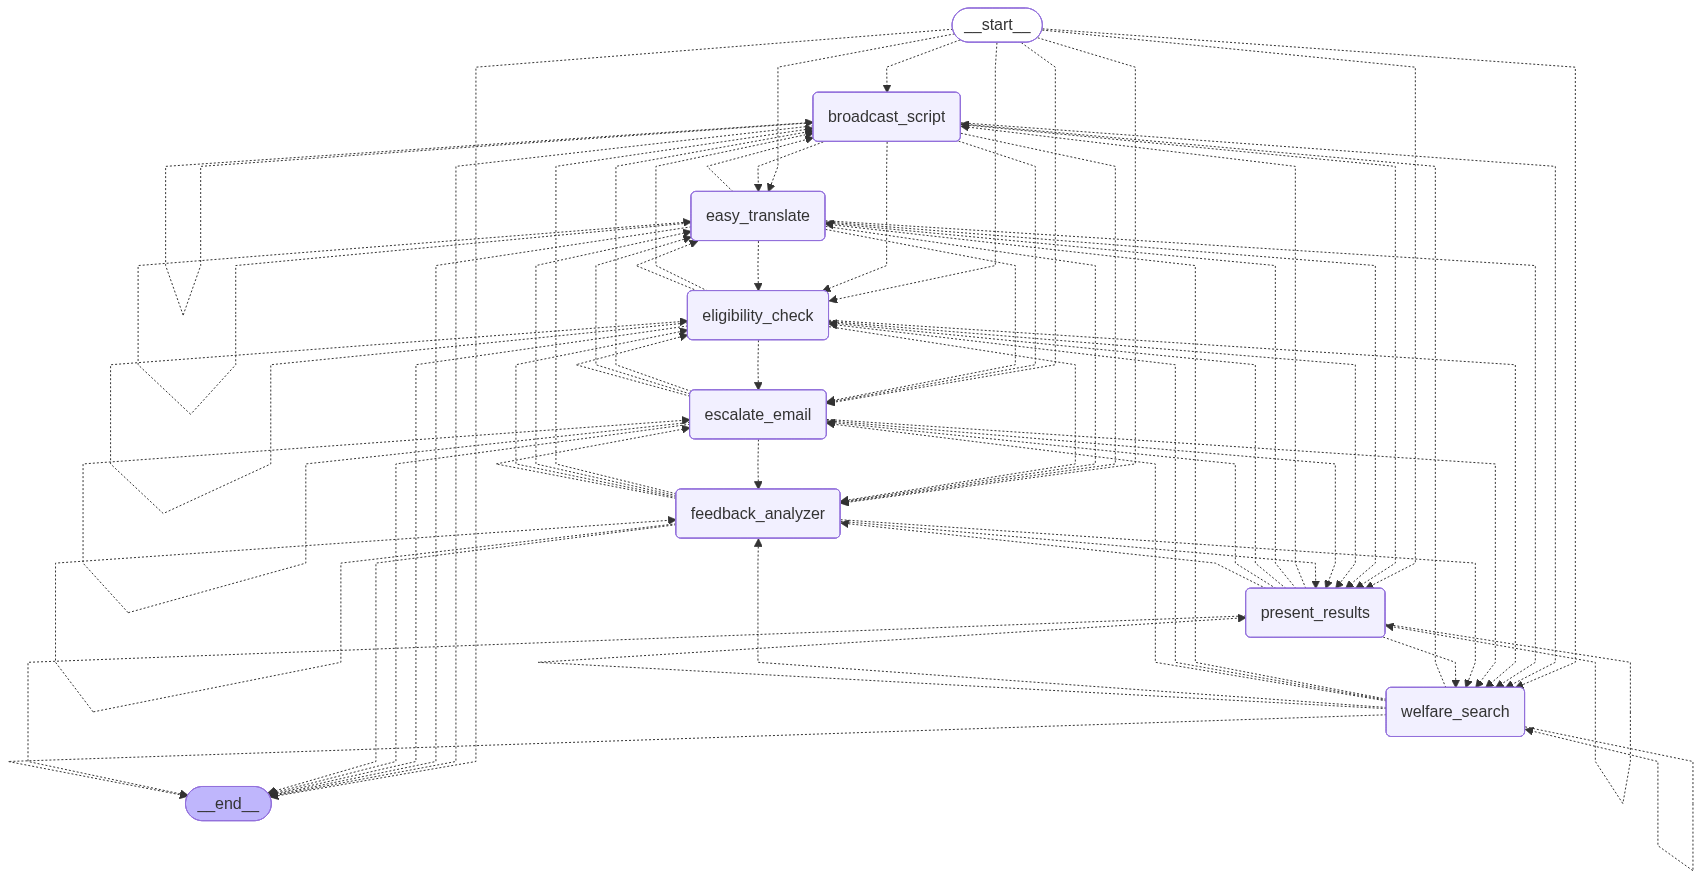

In [12]:
graph


## 10. LangFuse (선택)

In [13]:
langfuse_handler = None
if USE_LANGFUSE:
    from langfuse.langchain import CallbackHandler
    langfuse_handler = CallbackHandler()

def cfg(thread_id: str):
    c = {"configurable":{"thread_id":thread_id}}
    if langfuse_handler: c["callbacks"] = [langfuse_handler]
    return c
print("LangFuse:", "ON" if USE_LANGFUSE else "OFF")


LangFuse: ON


## 11. 시연 1 — 개인형 1턴 (UI [개인형] 버튼)

In [14]:
profile_grandma = {
    "age": 78, "region": "충청남도 부여군",
    "monthly_income": 800_000,
    "has_disability": False,
    # is_rural 생략 → "부여군"에서 자동 추론 (True)
    "is_single_household": True, "is_single_parent": False,
}

thread_personal = "demo-personal-001"

state_init = {
    "mode": "personal",
    "user_profile": profile_grandma,
    "messages": [HumanMessage(content="이장님~ 나도 받을 수 있는 노인 복지가 뭐가 있나 알아봐주세요.")],
    "raw_services": [], "eligible_benefits": [],
    "presented": False, "satisfaction": "", "email_sent": False,
    "easy_text": "", "broadcast_text": "", "feedback_summary": "",
}

# stream 모드로 실행 - 각 노드가 끝날 때마다 어떤 노드인지 + 상태 변화 출력
print("=" * 70)
print("🚀 [1턴 실행 시작] mode=personal")
print("=" * 70)
final_state = None
for chunk in graph.stream(state_init, config=cfg(thread_personal), stream_mode="updates"):
    for node_name, update in chunk.items():
        print(f"\n✅ 노드 [{node_name}] 완료")
        # 상태 변경 요약
        if "raw_services" in update:
            print(f"   → raw_services: {len(update['raw_services'])}건 수집")
        if "eligible_benefits" in update:
            print(f"   → eligible_benefits: {len(update['eligible_benefits'])}건 매칭")
        if "presented" in update:
            print(f"   → 결과 안내 생성 완료")
        if "messages" in update and update["messages"]:
            msg = update["messages"][-1].content
            print(f"   메시지: {msg[:200]}{'...' if len(msg) > 200 else ''}")
    final_state = chunk


# 마지막 안내 메시지만 별도로
print("\n" + "=" * 70)
print("[1턴 최종 안내]")
print("=" * 70)
result1 = graph.get_state(cfg(thread_personal)).values
print(result1["messages"][-1].content)


🚀 [1턴 실행 시작] mode=personal
📍 [1/3] welfare_search 진입 → 의도 추출 + Supabase 조회
  🔍 Tavily 호출: query='노인 충청남도 부여군 복지 지원 신청'
  📥 Tavily 결과: 3건
     [1] 복지서비스 상세(지자체) - 부여군 노인의날 기념식 및 건강100세 큰잔치
         URL: https://www.bokjiro.go.kr/ssis-tbu/twataa/wlfareIn
         내용: 지원대상. 관내 65세이상 어르신 및 효행자 ; 선정기준. 해당없음 ; 서비스 내용. 노인의 날 기념식 및 건강100세큰잔치(건강체조 경연대회) ; 신청방법...
     [2] [PDF] 치매공공후견 사례집 - 보건복지부
         URL: https://www.mohw.go.kr/upload/140/202008/159883211
         내용: 신청 연령(출생연도) 만 76세(1944년) 성별 남 치매정도 중등도치매 가족관계 무연고 소득수준 기초생활수급자 거주관련 임대주택 76 치매공공후견 사례집 치매공공후견 사례소개 7...
     [3] 힘이 되는 평생 친구, 보건복지부
         URL: https://www.mohw.go.kr
         내용: 사업별 홈페이지 _목록 열기_  # 사업별 홈페이지     기초연금    노인장기요양보험    사회서비스전자바우처    e하늘 장사종합정보    보건복지상담센터    보건복지부 자...
  🔗 DB 서비스명 ↔ Tavily 매칭 시도 (50개 DB 서비스 검사)
     ➕ 한시/신규 보완: '복지서비스 상세(지자체) - 부여군 노인의날 기념식 및 건강100세 큰잔치' (의도키워드 4개 매칭)
     ➕ 한시/신규 보완: '[PDF] 치매공공후견 사례집 - 보건복지부' (의도키워드 4개 매칭)
     ➕ 한시/신규 보완: '힘이 되는 평생 친구, 보건복지부' (의도키워드 5개 매칭)
  ➕ DB에 없던 한시/신규 

## 12. 시연 2 — 피드백 → SMTP 자동 전달

In [15]:
feedback = "이런 거 말고요, 우리 손주 대학 학비 지원 받을 수 있는 거 있나? 그게 더 급해요."

result2 = graph.invoke(
    {"messages":[HumanMessage(content=feedback)]},
    config=cfg(thread_personal),
)
print("=" * 70)
print(f"[2턴 - 피드백 분류: {result2.get('satisfaction')}]")
print("=" * 70)
for m in result2["messages"][-3:]:
    role = m.__class__.__name__.replace("Message","")
    print(f"\n[{role}]\n{m.content}\n")


📍 [feedback] feedback_analyzer 진입 → 피드백 분류
📍 [escalate] escalate_email 진입 → SMTP로 민원 담당자에게 전달
📧 [SMTP 미설정 - 미리보기]
To: 민원담당자@미설정 | Subject: [복지마을 방송국] 추가 상담 요청 - 충청남도 부여군 78세
------------------------------------------------------------
안녕하세요. 복지마을 방송국 AI 시스템에서 자동 전달드리는 민원입니다.

▣ 신청인 정보
   - 연령: 78세
   - 거주: 충청남도 부여군
   - 월소득: 800000원
   - 장애여부: 없음
   - 가구형태: 1인가구 

▣ AI가 안내한 복지
  - 노인 목욕비 및 이미용비 지원 (충청남도 부여군)
  - 매장유산 발굴조사 비용 국비지원 (국가유산청)
  - 저소득재가노인 밑반찬배달사업(추가) (충청남도 부여군)
  - 민간기업 노인고용장려금 (충청남도)
  - 충청남도 입원생활비 지원 (충청남도)

▣ 사용자 피드백 / 추가 요청
   제공된 정보 대신 손주의 대학 학비 지원에 대한 정보가 더 필요하다고 요청했습니다. [추가요청: 손주 대학 학비 지원]

▣ 요청사항
   위 내용을 바탕으로 추가 상담 또는 직권 안내를 부탁드립니다.

— 복지마을 방송국 AI 시스템 (2026 AI 챔피언 해커톤)

[2턴 - 피드백 분류: needs_more]

[Human]
이런 거 말고요, 우리 손주 대학 학비 지원 받을 수 있는 거 있나? 그게 더 급해요.


[AI]
[분류] needs_more / 제공된 정보 대신 손주의 대학 학비 지원에 대한 정보가 더 필요하다고 요청했습니다.


[AI]
📧 민원 담당자에게 전달 완료 (preview)
→ 민원담당자@미설정



## 13. 시연 3 — 마을방송 모드 (UI [마을방송] 버튼)

In [16]:
official_notice = """기초연금 신청 기간이 도래하였으니, 만 65세 이상 거주민께서는 신분증 및 통장 사본을 지참하시어 6월 15일까지 행정복지센터를 방문 바랍니다."""

result3 = graph.invoke(
    {
        "mode": "broadcast",
        "user_profile": {"dialect": "chungcheong"},
        "messages": [HumanMessage(content=official_notice)],
        "raw_services": [], "eligible_benefits": [],
        "presented": False, "satisfaction": "", "email_sent": False,
        "easy_text": "", "broadcast_text": "", "feedback_summary": "",
    },
    config=cfg("demo-broadcast-001"),
)

print("=" * 70, "\n[쉬운 말 변환]\n", "=" * 70)
print(result3.get("easy_text", "(없음)"))
print("\n", "=" * 70, "\n[마을 방송 스크립트]\n", "=" * 70)
print(result3.get("broadcast_text", "(없음)"))


📍 [방송 1/2] easy_translate 진입 → 행정공지 → 쉬운 말 변환
📍 [방송 2/2] broadcast_script 진입 → 마을 스피커 30초 멘트 생성
[쉬운 말 변환]
어르신들, 기초연금 신청할 때가 됐슈!

예순다섯 넘으신 어르신들은
신분증하고 통장 복사본을 꼭 챙겨오셔야 혀유.

유월 열닷새까지
우리 마을 행정복지센터로 오셔유.

궁금한 거 있으시면 언제든 물어보셔유!

[마을 방송 스크립트]
안녕하세요, 어르신 여러분. 마을 스피커 방송입니다.

어르신들의 편안한 노후를 위한 **기초연금 신청 기간**을 안내해 드립니다.

**만 65세 이상 어르신들**께서는 **신분증과 통장 사본**을 지참하시어,

**6월 15일 금요일까지** 우리 마을 **행정복지센터**를 방문해 주시기 바랍니다.

궁금한 점은 언제든지 문의해 주십시오. 감사합니다.


## 14. 다음 단계
1. UI 연결 (mode 버튼 + 결과 화면 + 피드백 입력)
2. 02번 노트북 매일 1회 Run All (지자체 상세 적재 자동 진행)
3. 검색 품질 개선 (pgvector 시맨틱 검색)
